<a href="https://colab.research.google.com/github/Anushka-Pokhriyal/delhi_NCR_properties/blob/main/delhiNCRproperties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
import os
os.listdir("data")

['real_estate_main.csv']

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
import os
os.listdir("data")

['real_estate_main.csv']

In [ ]:
df = pd.read_csv("data/real_estate_main.csv")

In [ ]:
for root, dirs, files in os.walk("data"):
    for file in files:
        print(root + "/" + file)

data/real_estate_main.csv


In [ ]:
df.head()
print(df.columns)
print(df.info())

Index(['Unnamed: 0', 'Name', 'Price', 'Rate', 'property', 'carpet.area',
       'status', 'floor', 'transaction', 'facing', 'overlooking', 'ownership',
       'parking', 'bathroom', 'balcony', 'city', 'location', 'Rate_per_sqft',
       'bedroom', 'carpet_area_sqft', 'total_area'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2345 non-null   int64  
 1   Name              2345 non-null   object 
 2   Price             2345 non-null   int64  
 3   Rate              2257 non-null   object 
 4   property          291 non-null    object 
 5   carpet.area       1198 non-null   object 
 6   status            2217 non-null   object 
 7   floor             2090 non-null   object 
 8   transaction       2344 non-null   object 
 9   facing            1270 non-null   object 
 10  overlooking       1

In [ ]:
df.columns = df.columns.str.lower().str.strip()

In [ ]:
df = df.rename(columns={
    'price': 'price',
    'area': 'area',
    'size': 'bhk',
    'bath': 'bathroom',
    'location': 'location'
})

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

In [ ]:
import numpy as np

def convert_price(x):
    x = str(x).lower()

    if 'cr' in x:
        return float(x.replace('cr','')) * 100
    elif 'lac' in x:
        return float(x.replace('lac',''))
    else:
        try:
            return float(x)
        except:
            return np.nan

df['price'] = df['price'].apply(convert_price)

In [ ]:
df = df.rename(columns={'size': 'area'})

In [ ]:
df.columns = df.columns.str.lower().str.strip()

print(df.columns)

Index(['unnamed: 0', 'name', 'price', 'rate', 'property', 'carpet.area',
       'status', 'floor', 'transaction', 'facing', 'overlooking', 'ownership',
       'parking', 'bathroom', 'balcony', 'city', 'location', 'rate_per_sqft',
       'bedroom', 'carpet_area_sqft', 'total_area'],
      dtype='object')


In [ ]:
df = df.rename(columns={
    'total_area': 'area',
    'bedroom': 'bhk'
})

In [ ]:
df = df[['location', 'area', 'bhk', 'bathroom', 'price']]

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

In [ ]:
df['area'] = pd.to_numeric(df['area'], errors='coerce')
df['bhk'] = pd.to_numeric(df['bhk'], errors='coerce')
df['bathroom'] = pd.to_numeric(df['bathroom'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df.dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 11013100.0
R2 Score: 0.5637592132359378


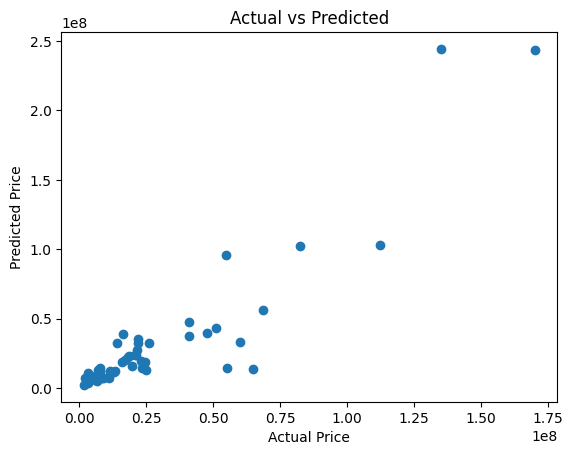

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

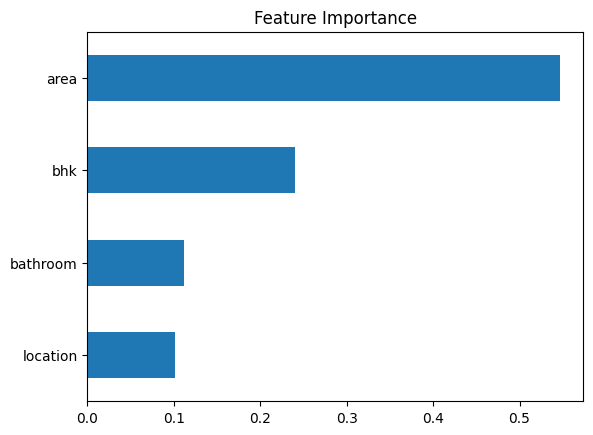

In [ ]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

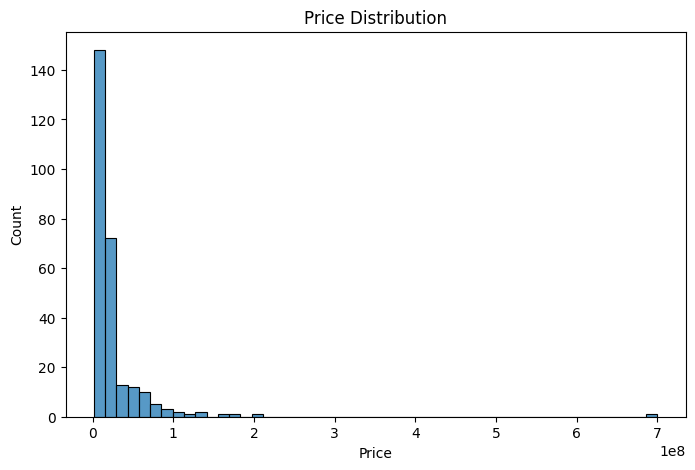

In [ ]:
#Price Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

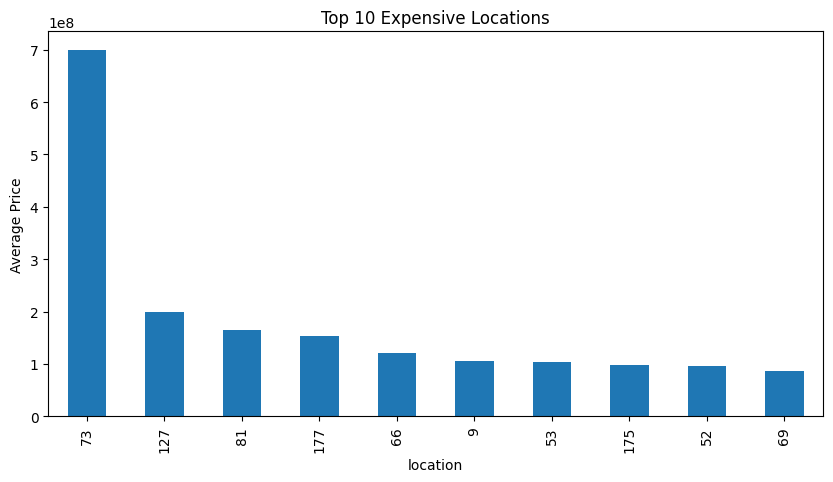

In [ ]:

#Top Locations by Average Price
top_locations = df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)

top_locations.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Expensive Locations")
plt.ylabel("Average Price")
plt.show()

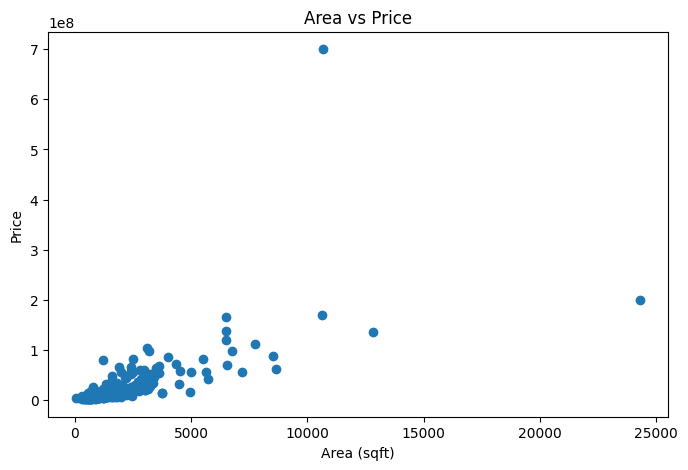

In [ ]:
  #Area vs Price
  plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'])
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

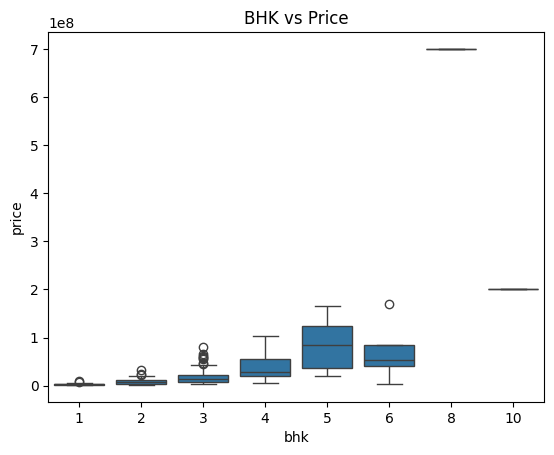

In [ ]:
#BHK vs Price
sns.boxplot(x=df['bhk'], y=df['price'])
plt.title("BHK vs Price")
plt.show()

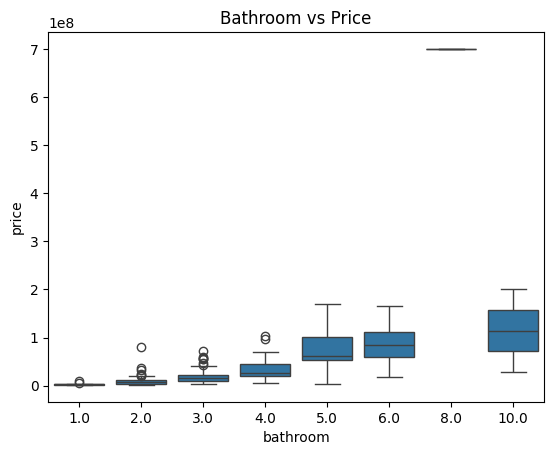

In [ ]:
#Bathroom vs Price
sns.boxplot(x=df['bathroom'], y=df['price'])
plt.title("Bathroom vs Price")
plt.show()


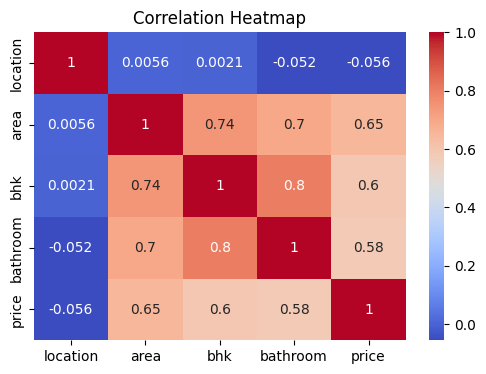

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

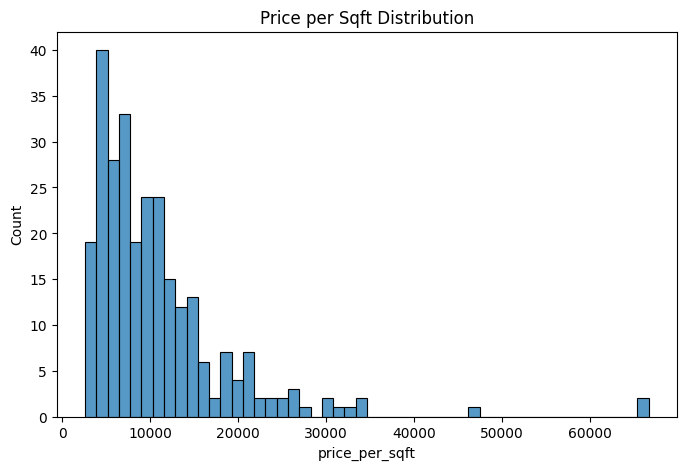

In [ ]:
#Price per Sqft
df['price_per_sqft'] = df['price'] / df['area']

plt.figure(figsize=(8,5))
sns.histplot(df['price_per_sqft'], bins=50)
plt.title("Price per Sqft Distribution")
plt.show()

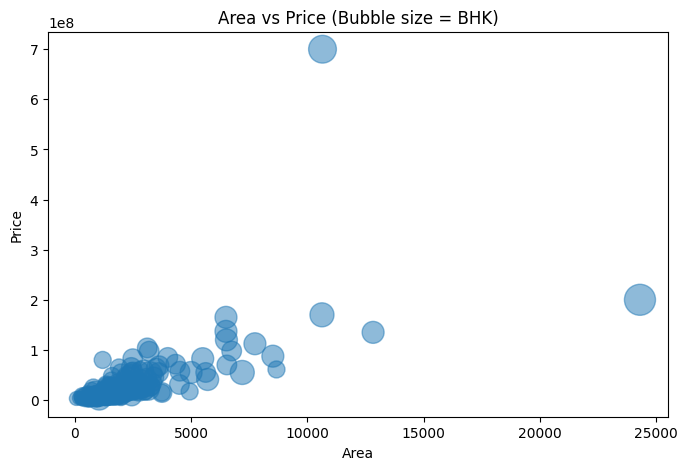

In [ ]:
#Bubble Plot
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'],
            s=df['bhk']*50, alpha=0.5)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price (Bubble size = BHK)")
plt.show()

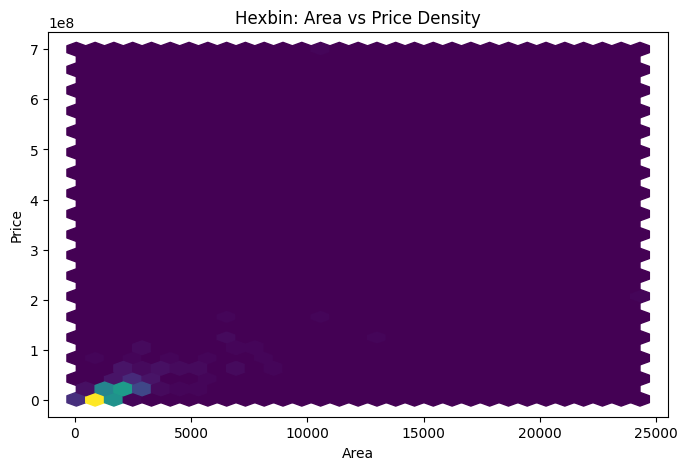

In [ ]:
#Hexbin Plot
plt.figure(figsize=(8,5))
plt.hexbin(df['area'], df['price'], gridsize=30)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Hexbin: Area vs Price Density")
plt.show()

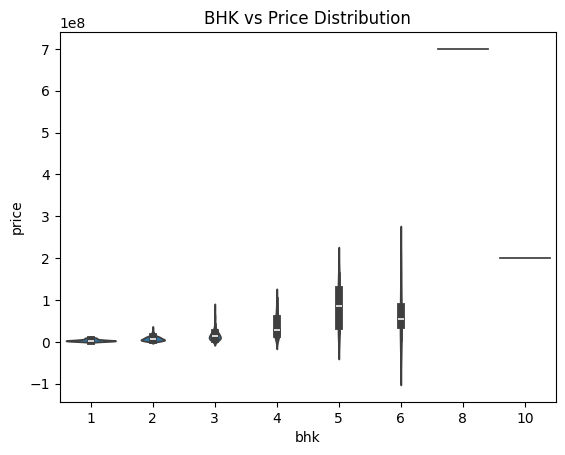

In [ ]:
#Violin Plot
sns.violinplot(x=df['bhk'], y=df['price'])
plt.title("BHK vs Price Distribution")
plt.show()

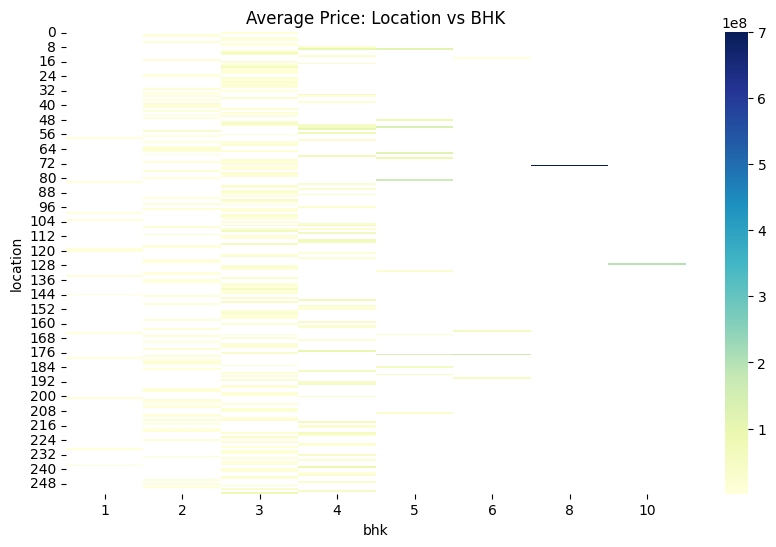

In [ ]:
#Location vs BHK Heatmap
pivot = pd.pivot_table(df,
                       values='price',
                       index='location',
                       columns='bhk',
                       aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Average Price: Location vs BHK")
plt.show()
